In [1]:
import os, sys, pickle
from importlib import reload
%pylab inline
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 2.5)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [5]:
from label_axes import label_axes

In [5]:
git_path = os.environ["GIT"]
sys.path.append(git_path)
if "GLOM_IO" not in os.environ:
    os.environ["GLOM_IO"] = os.path.join(git_path, "glom-io-transform-release")
proj_path = os.environ["GLOM_IO"]
assert os.path.exists(proj_path), f"Project path {proj_path} does not exist"
sys.path.append(proj_path)
sys.path.append(proj_path + "/model-fitting") 
sys.path.append(proj_path + "/analysis")
from label_axes import label_axes; reload(label_axes)

<module 'label_axes.label_axes' from '/camp/home/tootoos/working/tootoos/git/label_axes/label_axes.py'>

In [4]:
#import compute; reload(compute)
from glom_io_transform.analysis.compute import free as compute_free
reload(compute_free)
free_data = compute_free.Data().compute()

COMPUTING free.Data.
Loading models from self.base_dir='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std'
stats_include_diag=True
Path /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/ffree not found, skipping.


FileNotFoundError: [Errno 2] No such file or directory: '/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/ffree/collected.p'

PLOTTING FIGURE FitFree
PLOTTING PANELS Schem
PLOTTING PANELS FreeReps
include_diag=False
PLOTTING PANELS FreeConn
PLOTTING PANELS FreeConnModes
PLOTTING PANELS FreeConnModesHist


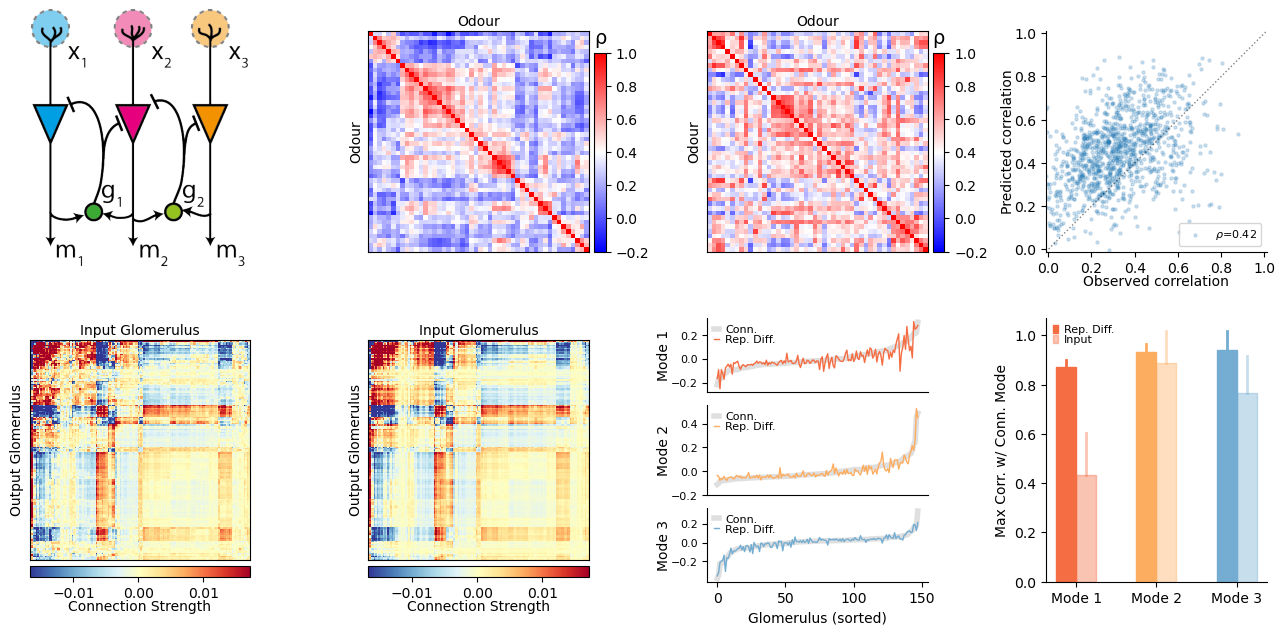

In [11]:
import figures as figures; reload(figures)
import figures.figures; reload(figures.figures)
from figures import free as fig_free; reload(figures.free)
from figures.figures import reduce_vertical_gaps 
fig = figure(figsize=(13, 6.5)); #title("HellO")
ax = fig_free.Main.plot(free_data)
tight_layout(h_pad=1., w_pad=0.5)
ax_vs = ax["fit_vs"]
ax_vs.set_xticks(arange(0, 1.1, 0.2))
ax_vs.set_yticks(arange(0, 1.1, 0.2))
ax_vs.set_xlabel("Observed correlation", labelpad=-0.5)
ax_vs.set_ylabel("Predicted correlation", labelpad=-0.5)
ax_modes = ax["modes"]
ax_hist = ax["hist"]
reduce_vertical_gaps(ax_modes, 0.1)

# Figure: Model Results

In [32]:
from compute import show_models as compute_show_models
reload(compute_show_models)
show_models_data = compute_show_models.Data().compute()

COMPUTING show_models.Data.
Loaded results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model_fitting/generalization_results.pkl.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model_fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


PLOTTING FIGURE FitDiag
PLOTTING PANELS Schem
PLOTTING PANELS Schem
Saved figure to /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/figs/fig_show_models.pdf


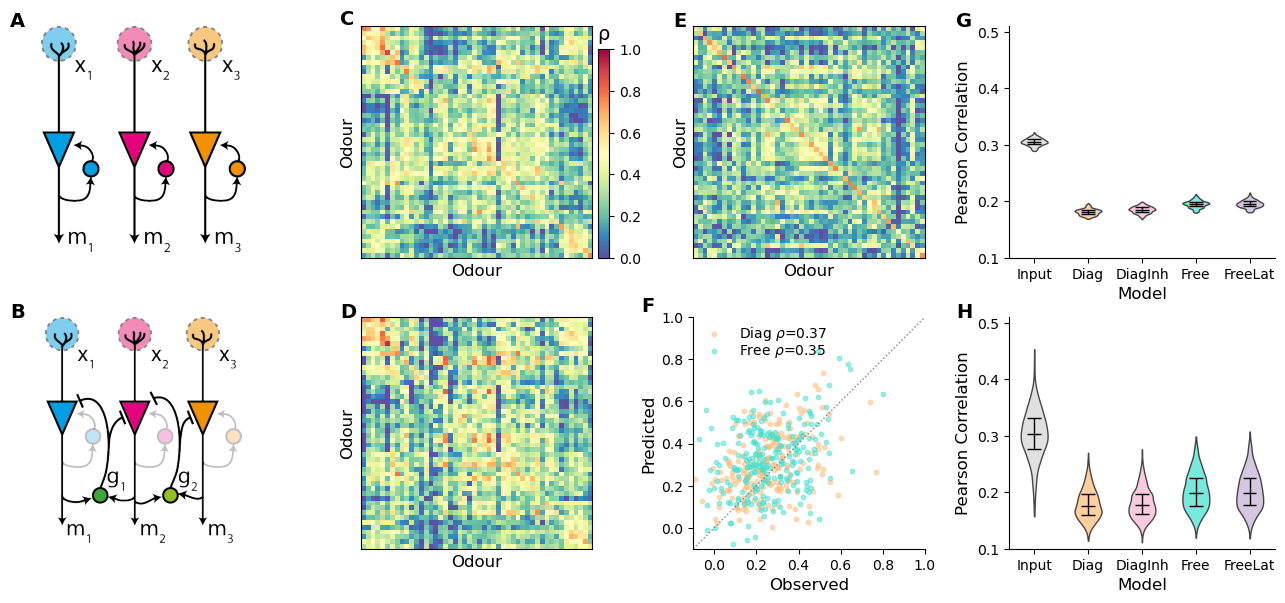

In [116]:
import analysis.figures; reload(analysis.figures)
from analysis.figures import figures as figures_figures; reload(figures_figures)
from analysis.figures import show_models as fig_show_models; reload(fig_show_models)
fig = figure(figsize=(13, 6)); #title("HellO")
ax = fig_show_models.Main.plot(show_models_data)#, free_corr_energy=free_data.corr_energy)
tight_layout(w_pad=0.5)
label_axes.label_axes([ax[k] for k in ax], "ABCDEFGH", fontsize=14, fontweight="bold")
fig_file = f"{proj_path}/figs/fig_show_models.pdf"
savefig(fig_file, bbox_inches="tight", dpi=600)
print(f"Saved figure to {fig_file}")